In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
features_t0 = ["E2", "E3", "M1", "M9", "M11", "M13", "P2", "P5", "P8", "P10", "P11", "S2", "S3", "S8", "V7", "V9", "V10"]
features_t1 = features_t0 + ["E19", "M12", "S5", "V13"]

In [3]:
f_corr = pd.read_pickle("Analysis/f_corr_overall.pkl")
f_rank_corr = pd.read_pickle("Analysis/f_rank_corr_overall.pkl")

In [4]:
f_corr.droplevel(0).droplevel(0, axis=1).loc[features_t0, features_t0]

Feature,E2,E3,M1,M9,M11,M13,P2,P5,P8,P10,P11,S2,S3,S8,V7,V9,V10
Feature,,,,,,,,,,,,,,,,,
E2,1.0,0.992693,-0.748829,0.794303,-0.710476,-0.520784,-0.979744,0.501852,0.639024,0.763076,0.98427,0.60228,0.572745,0.771948,-0.665581,-0.674922,-0.683601
E3,0.992693,1.0,-0.756635,0.766686,-0.681982,-0.554388,-0.970783,0.503476,0.664761,0.789224,0.984191,0.604655,0.577328,0.781316,-0.689424,-0.698605,-0.706638
M1,-0.748829,-0.756635,1.0,-0.682228,0.584983,0.60582,0.750439,-0.46357,-0.637972,-0.724354,-0.792293,-0.646274,-0.607959,-0.717891,0.825458,0.829915,0.819999
M9,0.794303,0.766686,-0.682228,1.0,-0.781919,-0.391054,-0.796362,0.408257,0.493327,0.601078,0.80441,0.526035,0.54882,0.651842,-0.557469,-0.561263,-0.562504
M11,-0.710476,-0.681982,0.584983,-0.781919,1.0,0.425249,0.712285,-0.46786,-0.404431,-0.541801,-0.718514,-0.575842,-0.522599,-0.696505,0.480207,0.492722,0.498917
M13,-0.520784,-0.554388,0.60582,-0.391054,0.425249,1.0,0.521496,-0.376176,-0.434001,-0.559032,-0.556812,-0.479902,-0.394849,-0.613215,0.611632,0.681753,0.73147
P2,-0.979744,-0.970783,0.750439,-0.796362,0.712285,0.521496,1.0,-0.48574,-0.62902,-0.762391,-0.974023,-0.599067,-0.567894,-0.761557,0.669794,0.680707,0.689739
P5,0.501852,0.503476,-0.46357,0.408257,-0.46786,-0.376176,-0.48574,1.0,0.367746,0.470786,0.528828,0.509695,0.410005,0.484371,-0.449734,-0.456269,-0.454247
P8,0.639024,0.664761,-0.637972,0.493327,-0.404431,-0.434001,-0.62902,0.367746,1.0,0.754973,0.656467,0.371657,0.355206,0.464576,-0.638716,-0.643796,-0.634301


In [5]:
f_corr_t0 = f_corr.droplevel(0).droplevel(0, axis=1).loc[features_t0, features_t0]
f_corr_t1 = f_corr.droplevel(0).droplevel(0, axis=1).loc[features_t1, features_t1]

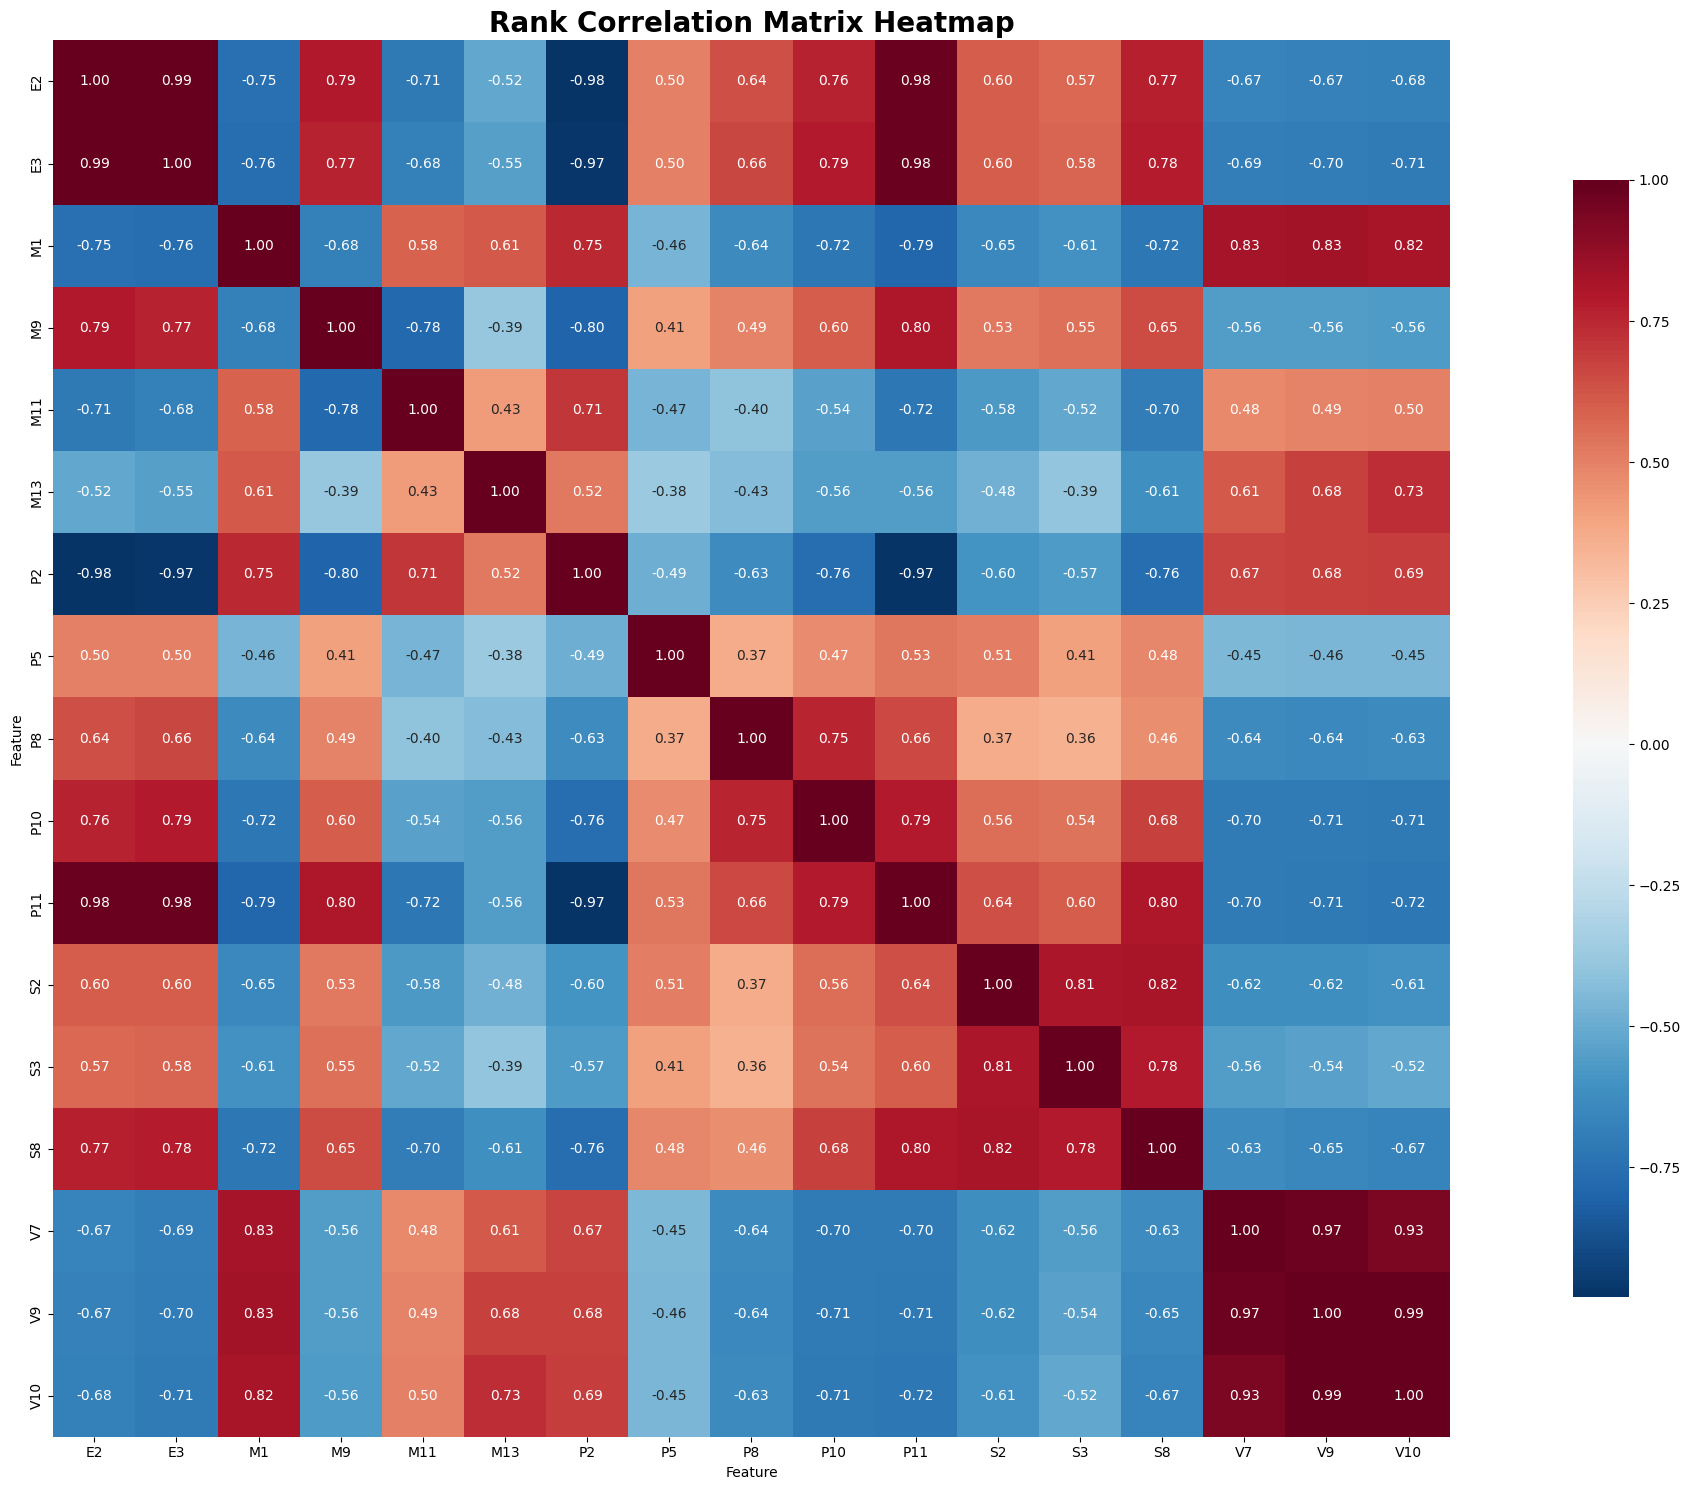

In [6]:
plt.figure(figsize=(25, 15))
sns.heatmap(f_corr_t0.astype(float), 
            annot=True, 
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt=".2f",
            cbar_kws={"shrink": .8})

plt.title('Rank Correlation Matrix Heatmap', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

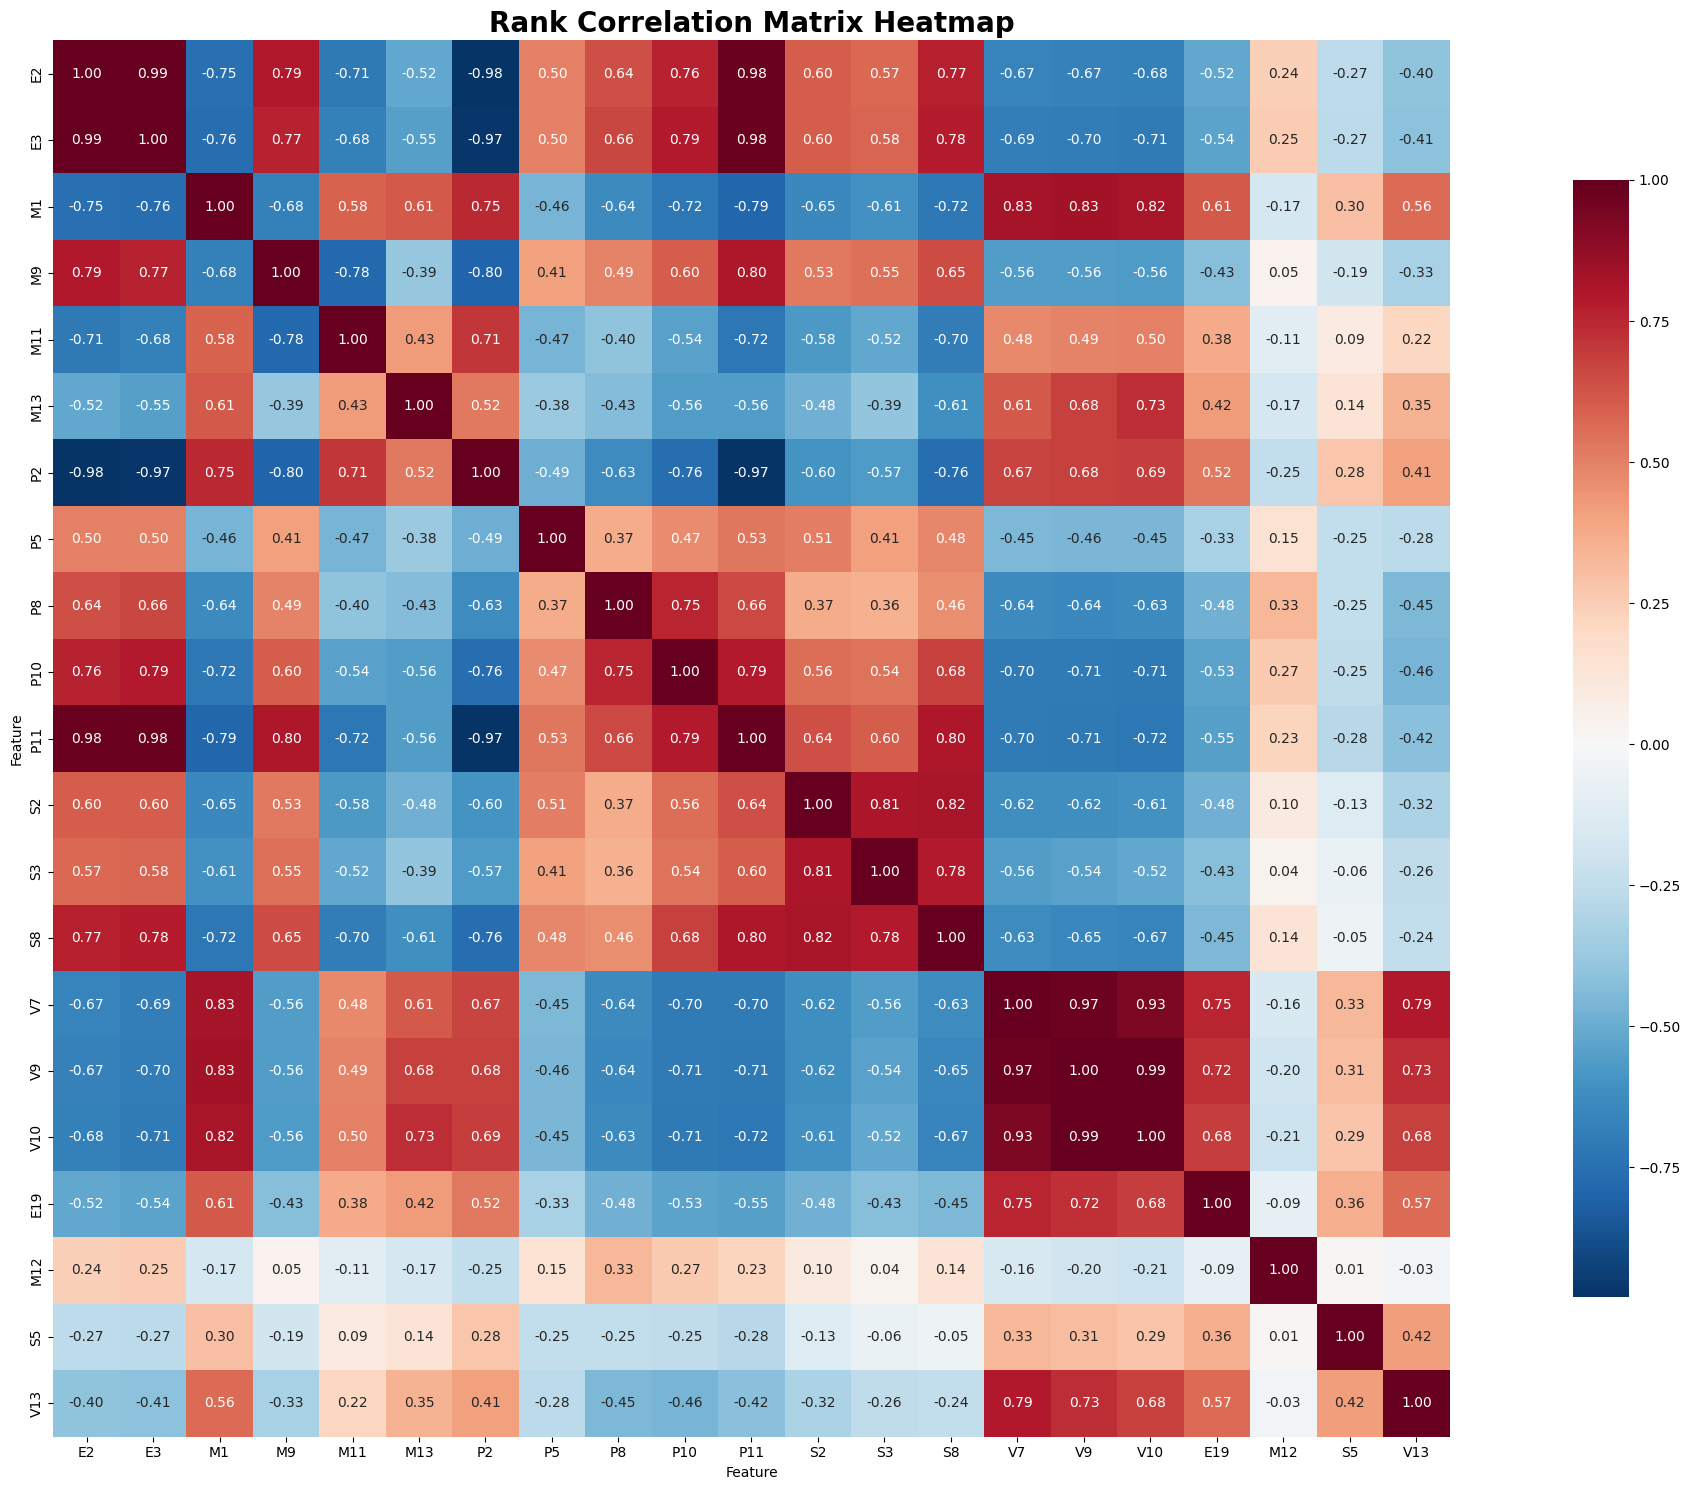

In [7]:
plt.figure(figsize=(25, 15))
sns.heatmap(f_corr_t1.astype(float), 
            annot=True, 
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt=".2f",
            cbar_kws={"shrink": .8})

plt.title('Rank Correlation Matrix Heatmap', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
valid_features_t0 = []
valid = [True] * len(features_t0)
for i in range(len(features_t0)):
    for j in range(i):
        if abs(f_corr_t0.iloc[i, j]) > 0.7 and valid[j]:
            valid[i] = False
    if valid[i]:
        valid_features_t0.append(features_t0[i])
        
valid_features_t1 = []
valid = [True] * len(features_t1)
for i in range(len(features_t1)):
    for j in range(i):
        if abs(f_corr_t1.iloc[i, j]) > 0.7 and valid[j]:
            valid[i] = False
    if valid[i]:
        valid_features_t1.append(features_t1[i])

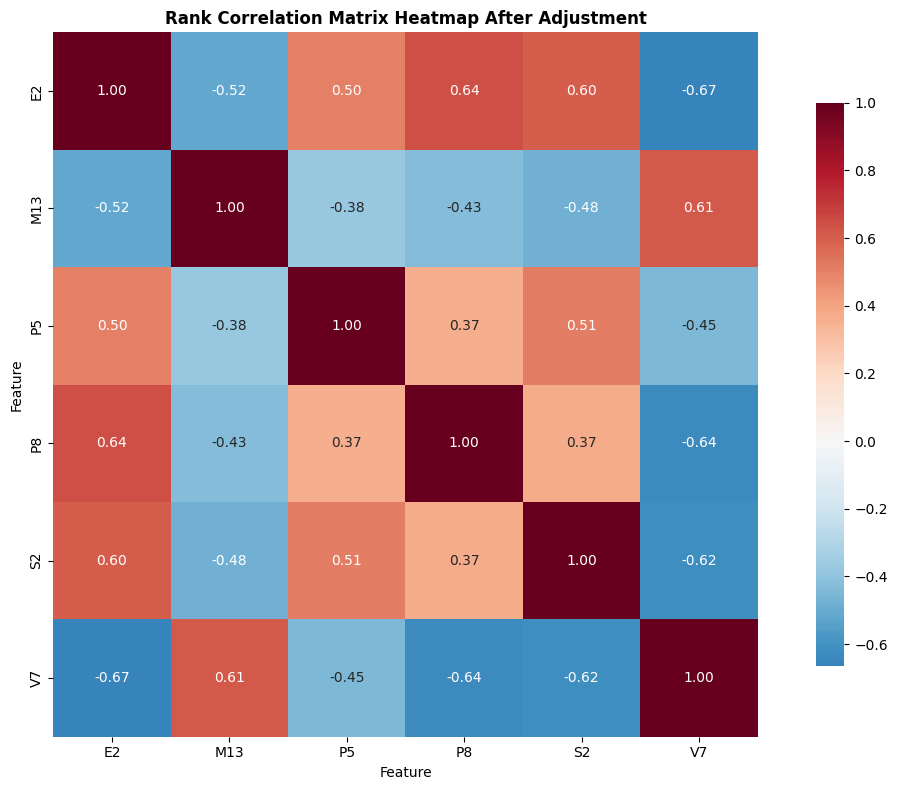

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(f_corr_t1.loc[valid_features_t0, valid_features_t0].astype(float), 
            annot=True, 
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt=".2f",
            cbar_kws={"shrink": .8})

plt.title('Rank Correlation Matrix Heatmap After Adjustment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

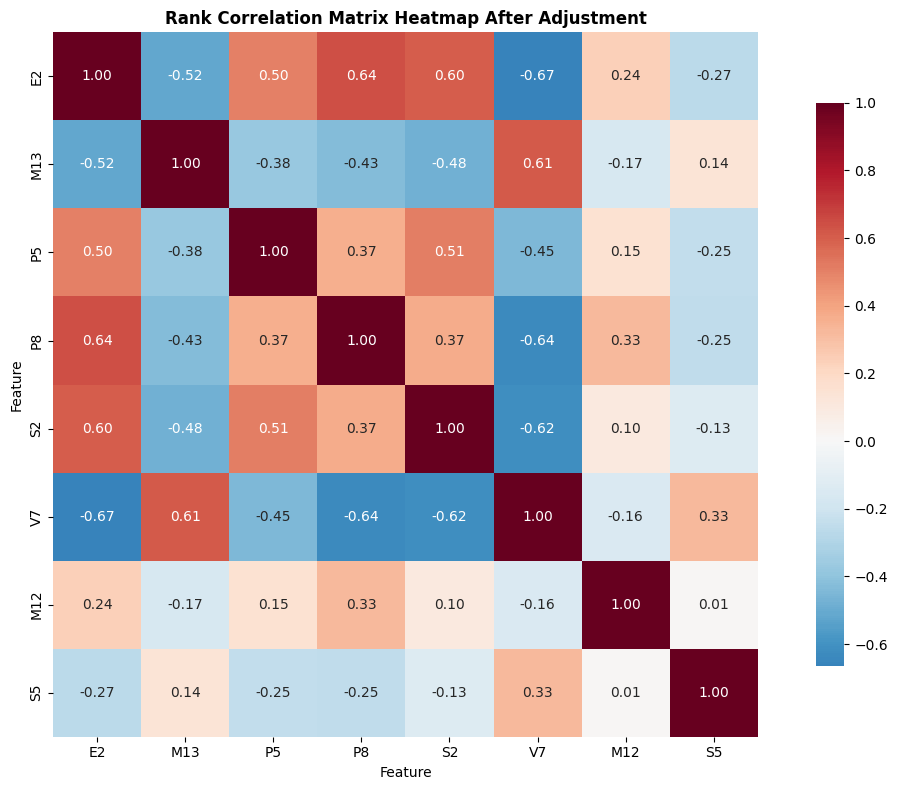

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(f_corr_t1.loc[valid_features_t1, valid_features_t1].astype(float), 
            annot=True, 
            cmap='RdBu_r',
            center=0,
            square=True,
            fmt=".2f",
            cbar_kws={"shrink": .8})

plt.title('Rank Correlation Matrix Heatmap After Adjustment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
valid_features_t1

['E2', 'M13', 'P5', 'P8', 'S2', 'V7', 'M12', 'S5']